✅ Step 1 Done — Libraries loaded
✅ Step 2 Done — Data loaded: (5000, 35)
✅ Step 3 Done — Customer features built
   Total : 400
   Churned: 47
   Active : 353

ML MODEL 1 — CHURN PREDICTION
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        71
           1       1.00      1.00      1.00         9

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



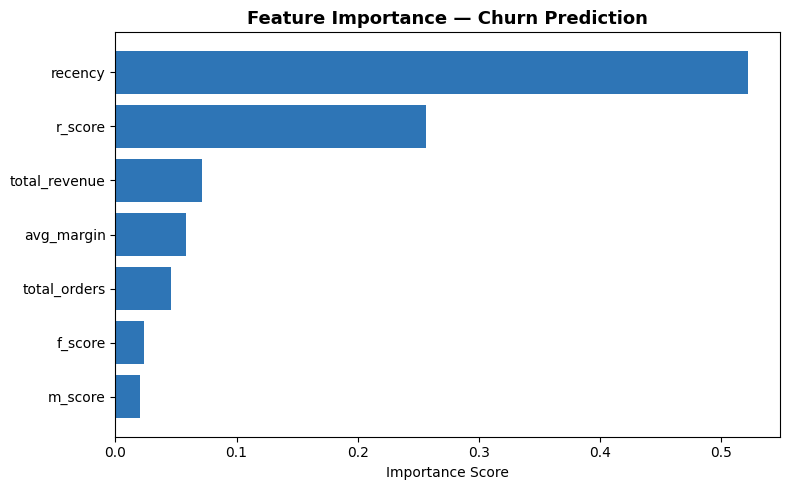

✅ ML Model 1 Done

ML MODEL 2 — CUSTOMER CLUSTERING


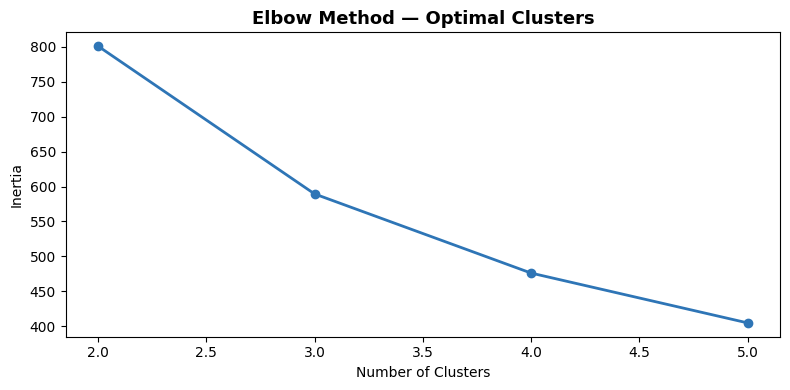

cluster_label  customers  avg_revenue  avg_orders  avg_recency
      At Risk         60      4369.48       10.43       237.25
   High Value        134      4650.78        9.56        58.35
    Low Value         66     13329.15       15.65        52.45
 Medium Value        140      6178.06       14.71        53.90


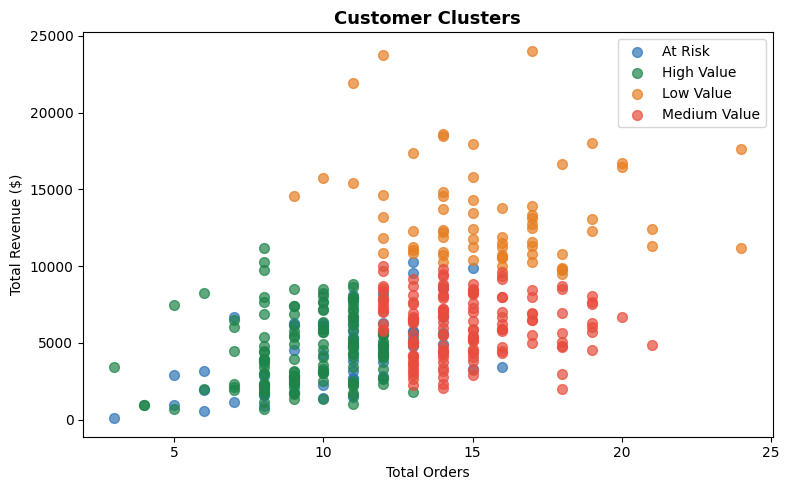

✅ ML Model 2 Done

ML MODEL 3 — SALES FORECASTING
R² Score: 0.006
  Month + 1: $75,194
  Month + 2: $75,309
  Month + 3: $75,425
  Month + 4: $75,540
  Month + 5: $75,656
  Month + 6: $75,771
  Month + 7: $75,887
  Month + 8: $76,002
  Month + 9: $76,118
  Month +10: $76,233
  Month +11: $76,349
  Month +12: $76,464


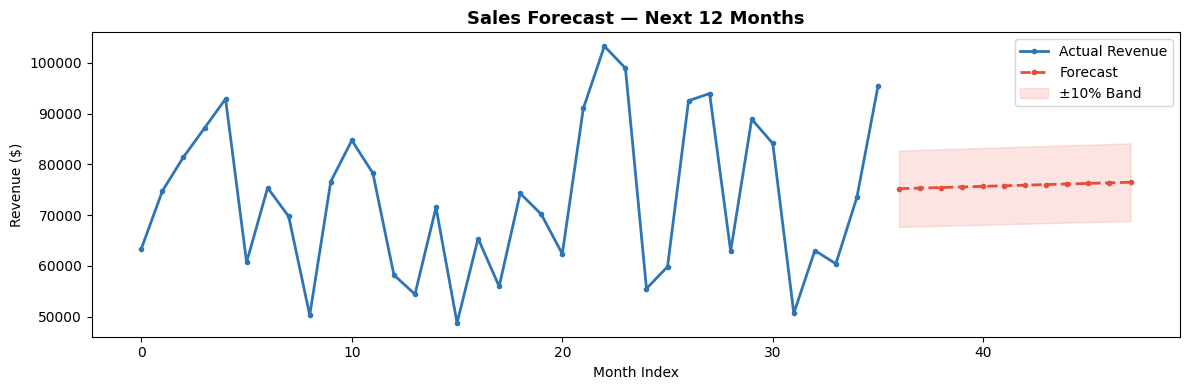

✅ ML Model 3 Done

🎉 ALL 3 ML MODELS COMPLETED!
✅ ML Model 1 → Churn Prediction
✅ ML Model 2 → Customer Clustering
✅ ML Model 3 → Sales Forecasting


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

# ── PATH SETUP ────────────────────────────────────────────────
BASE   = r'C:\Users\USER\Documents\sales-analytics-project\sales-analytics-project'
DATA   = os.path.join(BASE, 'data')
IMAGES = os.path.join(BASE, 'images')
print('✅ Step 1 Done — Libraries loaded')

# ── LOAD DATA ─────────────────────────────────────────────────
df = pd.read_csv(
    os.path.join(DATA, 'cleaned_sales_data.csv'),
    parse_dates=['order_date']
)
print(f'✅ Step 2 Done — Data loaded: {df.shape}')

# ── BUILD CUSTOMER FEATURES ───────────────────────────────────
customer_features = df.groupby('customer_id').agg(
    total_orders    = ('order_id',     'nunique'),
    total_revenue   = ('revenue',      'sum'),
    total_profit    = ('profit',       'sum'),
    avg_order_value = ('revenue',      'mean'),
    avg_margin      = ('profit_margin','mean'),
    recency         = ('order_date',
                       lambda x: (df['order_date'].max()
                                  - x.max()).days),
    r_score         = ('r_score',      'first'),
    f_score         = ('f_score',      'first'),
    m_score         = ('m_score',      'first')
).reset_index()

customer_features['churned'] = (
    customer_features['recency'] > 180
).astype(int)

print(f'✅ Step 3 Done — Customer features built')
print(f'   Total : {len(customer_features)}')
print(f'   Churned: {customer_features["churned"].sum()}')
print(f'   Active : {(customer_features["churned"]==0).sum()}')

# ── ML MODEL 1: CHURN PREDICTION (FASTER) ────────────────────
print('\n' + '='*50)
print('ML MODEL 1 — CHURN PREDICTION')
print('='*50)

features = ['total_orders','total_revenue',
            'avg_margin','recency',
            'r_score','f_score','m_score']

X = customer_features[features]
y = customer_features['churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# FASTER — only 10 trees instead of 100
rf_model = RandomForestClassifier(
    n_estimators=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

print(classification_report(y_test, y_pred))

# Feature importance chart
importance = pd.DataFrame({
    'feature':    features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importance['feature'],
        importance['importance'],
        color='#2E75B6')
ax.set_title('Feature Importance — Churn Prediction',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig(os.path.join(IMAGES,
            '06_churn_feature_importance.png'),
            dpi=100, bbox_inches='tight')
plt.show()
print('✅ ML Model 1 Done')

# ── ML MODEL 2: CLUSTERING (FASTER) ──────────────────────────
print('\n' + '='*50)
print('ML MODEL 2 — CUSTOMER CLUSTERING')
print('='*50)

cluster_data = customer_features[
    ['total_revenue','total_orders','recency']
].copy()

scaler = StandardScaler()
scaled = scaler.fit_transform(cluster_data)

# FASTER — only test K=2 to 5 instead of 2 to 8
inertia = []
for k in range(2, 6):
    km = KMeans(n_clusters=k,
                random_state=42,
                n_init=5,        # FASTER — 5 instead of 10
                max_iter=100)    # FASTER — limit iterations
    km.fit(scaled)
    inertia.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(2, 6), inertia,
        marker='o', color='#2E75B6', linewidth=2)
ax.set_title('Elbow Method — Optimal Clusters',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Clusters')
ax.set_ylabel('Inertia')
plt.tight_layout()
plt.savefig(os.path.join(IMAGES, '07_elbow_curve.png'),
            dpi=100, bbox_inches='tight')
plt.show()

# Apply K=4
kmeans = KMeans(n_clusters=4,
                random_state=42,
                n_init=5,
                max_iter=100)
customer_features['cluster'] = kmeans.fit_predict(scaled)

cluster_labels = {
    0: 'High Value',
    1: 'Medium Value',
    2: 'Low Value',
    3: 'At Risk'
}
customer_features['cluster_label'] = (
    customer_features['cluster'].map(cluster_labels)
)

cluster_summary = customer_features.groupby(
    'cluster_label'
).agg(
    customers   = ('customer_id',   'count'),
    avg_revenue = ('total_revenue', 'mean'),
    avg_orders  = ('total_orders',  'mean'),
    avg_recency = ('recency',       'mean')
).round(2).reset_index()

print(cluster_summary.to_string(index=False))

colors = ['#2E75B6','#1E8449','#E67E22','#E74C3C']
fig, ax = plt.subplots(figsize=(8, 5))
for i, (label, group) in enumerate(
    customer_features.groupby('cluster_label')
):
    ax.scatter(
        group['total_orders'],
        group['total_revenue'],
        label=label,
        color=colors[i % len(colors)],
        alpha=0.7, s=50
    )
ax.set_title('Customer Clusters',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Total Orders')
ax.set_ylabel('Total Revenue ($)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(IMAGES,
            '08_customer_clusters.png'),
            dpi=100, bbox_inches='tight')
plt.show()
print('✅ ML Model 2 Done')

# ── ML MODEL 3: FORECASTING ───────────────────────────────────
print('\n' + '='*50)
print('ML MODEL 3 — SALES FORECASTING')
print('='*50)

monthly = df.groupby('month_year')['revenue'].sum(
).reset_index().sort_values(
    'month_year').reset_index(drop=True)
monthly['month_index'] = range(len(monthly))

lr_model = LinearRegression()
lr_model.fit(monthly[['month_index']], monthly['revenue'])

print(f'R² Score: {lr_model.score(monthly[["month_index"]], monthly["revenue"]):.3f}')

future_idx = pd.DataFrame({
    'month_index': range(len(monthly), len(monthly) + 12)
})
future_revenue = lr_model.predict(future_idx)

for i, rev in enumerate(future_revenue, 1):
    print(f'  Month +{i:2d}: ${rev:,.0f}')

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly['month_index'],
        monthly['revenue'],
        color='#2E75B6', linewidth=2,
        marker='o', markersize=3,
        label='Actual Revenue')
ax.plot(future_idx['month_index'],
        future_revenue,
        color='#E74C3C', linewidth=2,
        linestyle='--', marker='o',
        markersize=3, label='Forecast')
ax.fill_between(
    future_idx['month_index'],
    future_revenue * 0.90,
    future_revenue * 1.10,
    alpha=0.15, color='#E74C3C',
    label='±10% Band'
)
ax.set_title('Sales Forecast — Next 12 Months',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Month Index')
ax.set_ylabel('Revenue ($)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(IMAGES, '09_ml_forecast.png'),
            dpi=100, bbox_inches='tight')
plt.show()
print('✅ ML Model 3 Done')

# ── SAVE RESULTS ──────────────────────────────────────────────
customer_features.to_csv(
    os.path.join(DATA, 'ml_customer_analysis.csv'),
    index=False
)
cluster_summary.to_csv(
    os.path.join(DATA, 'ml_cluster_summary.csv'),
    index=False
)

print('\n' + '='*50)
print('🎉 ALL 3 ML MODELS COMPLETED!')
print('='*50)
print('✅ ML Model 1 → Churn Prediction')
print('✅ ML Model 2 → Customer Clustering')
print('✅ ML Model 3 → Sales Forecasting')

✅ Data loaded

Historical Data: 36 months
month_year  total_sales  total_orders
   2022-01     63382.74           139
   2022-02     74749.07           129
   2022-03     81416.46           140
   2022-04     87126.46           138
   2022-05     92885.39           149
   2022-06     60706.08           130
   2022-07     75365.41           158
   2022-08     69727.15           141
   2022-09     50257.61           136
   2022-10     76604.50           156
   2022-11     84712.59           140
   2022-12     78252.10           145
   2023-01     58199.96           133
   2023-02     54400.97           120
   2023-03     71497.22           145
   2023-04     48760.15           130
   2023-05     65378.56           142
   2023-06     55941.00           125
   2023-07     74274.89           146
   2023-08     70160.94           133
   2023-09     62347.05           127
   2023-10     91008.81           147
   2023-11    103268.45           137
   2023-12     98933.69           135
   2024-

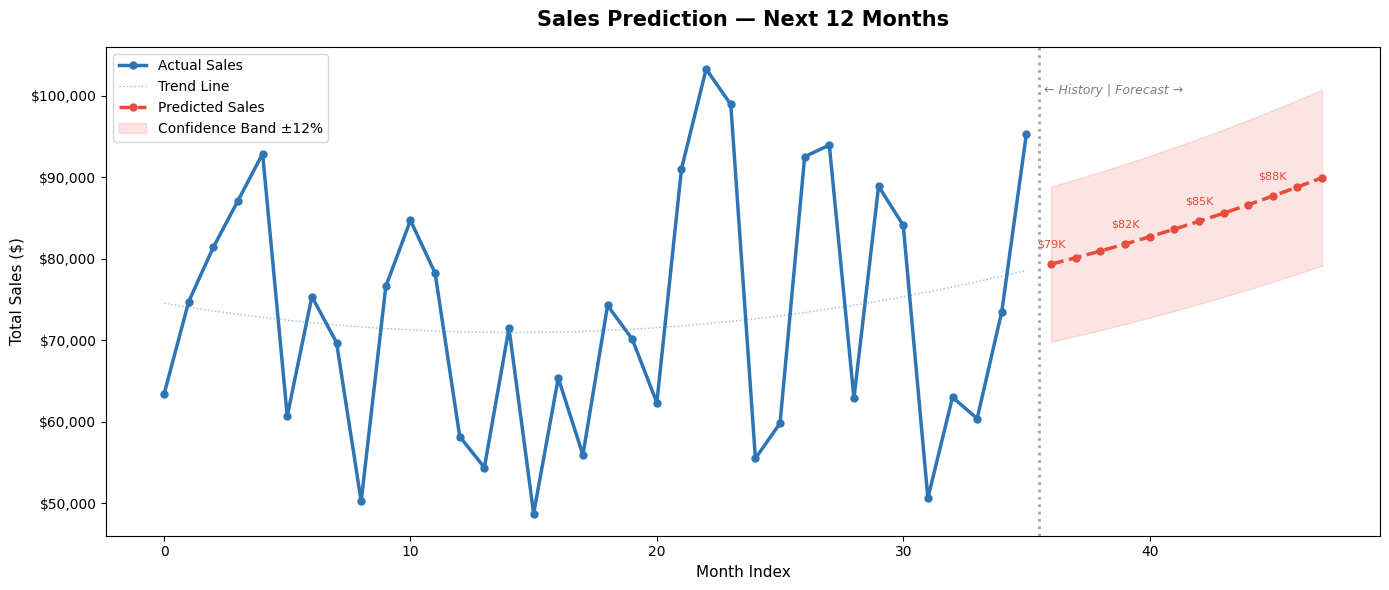


✅ Chart 1 saved — Historical + Future Sales


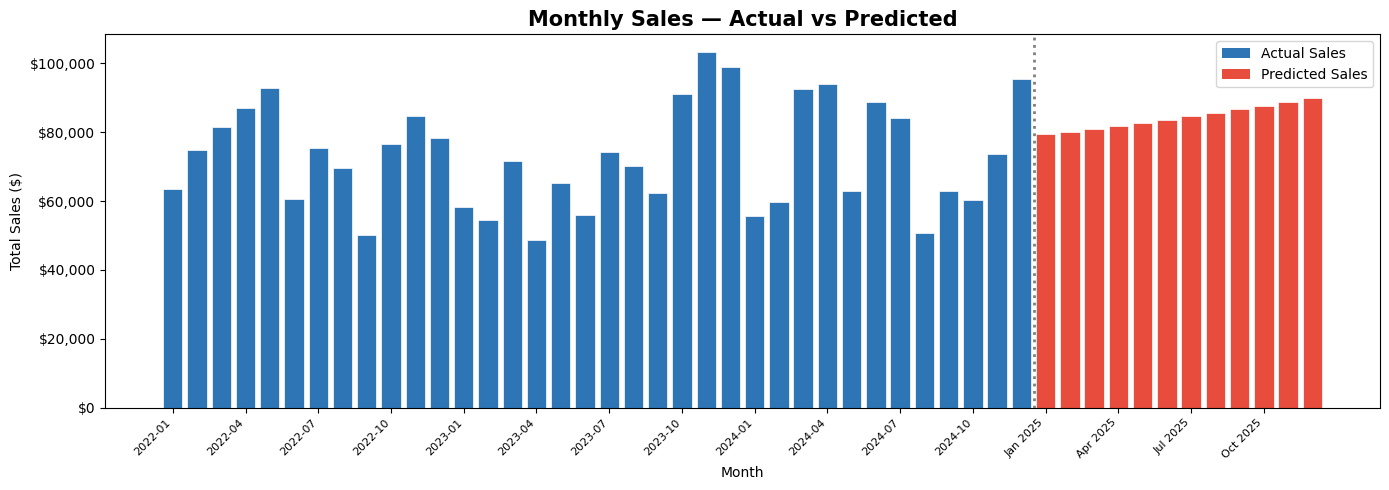

✅ Chart 2 saved — Monthly Bar Chart

🎉 FUTURE SALES PREDICTION COMPLETED!
✅ Model R² Score : 0.019
✅ Months Predicted: 12
✅ Total Forecast  : $1,011,788
✅ Monthly Average : $84,316

📄 File saved:
   future_sales_prediction.csv

📊 Charts saved:
   10_future_sales_prediction.png
   11_sales_bar_prediction.png


In [10]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')
parent = os.path.dirname(os.getcwd())
data   = os.path.join(parent, 'data')
images = os.path.join(parent, 'images')
df = pd.read_csv(
    os.path.join(data, 'cleaned_sales_data.csv'),
    parse_dates=['order_date']
)
print('✅ Data loaded')

# ── PREPARE MONTHLY SALES DATA ────────────────────────────────
monthly = df.groupby('month_year').agg(
    total_sales    = ('revenue',   'sum'),
    total_orders   = ('order_id',  'nunique'),
    total_quantity = ('quantity',  'sum'),
    total_profit   = ('profit',    'sum')
).reset_index().sort_values('month_year').reset_index(drop=True)

monthly['month_index'] = range(len(monthly))

print(f'\nHistorical Data: {len(monthly)} months')
print(monthly[['month_year',
               'total_sales',
               'total_orders']].to_string(index=False))

# ── TRAIN SALES PREDICTION MODEL ──────────────────────────────
X = monthly[['month_index']]
y = monthly['total_sales']

# Polynomial Regression degree 2
model = make_pipeline(
    PolynomialFeatures(degree=2),
    LinearRegression()
)
model.fit(X, y)

# Model accuracy
y_pred_train = model.predict(X)
r2  = r2_score(y, y_pred_train)
mae = mean_absolute_error(y, y_pred_train)

print(f'\nModel Accuracy:')
print(f'  R² Score : {r2:.3f}  (closer to 1 = better)')
print(f'  MAE      : ${mae:,.0f}  (avg prediction error)')

# ── PREDICT NEXT 12 MONTHS SALES ──────────────────────────────
print('\n' + '='*55)
print('FUTURE SALES PREDICTION — NEXT 12 MONTHS')
print('='*55)

# Future month indices
future_idx = pd.DataFrame({
    'month_index': range(len(monthly), len(monthly) + 12)
})

# Predict
future_sales = model.predict(future_idx)
future_sales = np.maximum(future_sales, 0)

# Generate month labels
last_date     = pd.to_datetime('2024-12-01')
future_labels = pd.date_range(
    start   = last_date + pd.DateOffset(months=1),
    periods = 12,
    freq    = 'MS'
).strftime('%b %Y')

# Print predictions
print(f'\n{"Month":<12} {"Predicted Sales":>18} {"vs Avg":>12}')
print('-'*44)
avg_historical = monthly['total_sales'].mean()
total_predicted = 0

for label, sales in zip(future_labels, future_sales):
    diff_pct     = (sales - avg_historical) / avg_historical * 100
    trend        = '📈' if diff_pct > 0 else '📉'
    total_predicted += sales
    print(f'{label:<12} ${sales:>15,.0f}  {trend}{diff_pct:>+.1f}%')

print('-'*44)
print(f'{"Total":<12} ${total_predicted:>15,.0f}')
print(f'{"Monthly Avg":<12} ${total_predicted/12:>15,.0f}')

# ── CHART 1: HISTORICAL + FUTURE SALES ───────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

# Historical actual
ax.plot(monthly['month_index'],
        monthly['total_sales'],
        color='#2E75B6', linewidth=2.5,
        marker='o', markersize=5,
        label='Actual Sales', zorder=3)

# Historical fitted line
ax.plot(monthly['month_index'],
        y_pred_train,
        color='#2E75B6', linewidth=1,
        linestyle=':', alpha=0.5,
        label='Trend Line')

# Future predictions
ax.plot(future_idx['month_index'],
        future_sales,
        color='#E74C3C', linewidth=2.5,
        linestyle='--', marker='o',
        markersize=5, label='Predicted Sales',
        zorder=3)

# Confidence band
ax.fill_between(
    future_idx['month_index'],
    future_sales * 0.88,
    future_sales * 1.12,
    alpha=0.15, color='#E74C3C',
    label='Confidence Band ±12%'
)

# Divider
ax.axvline(x=len(monthly)-0.5,
           color='gray', linestyle=':',
           linewidth=2, alpha=0.7)
ax.text(len(monthly)-0.3,
        monthly['total_sales'].max() * 0.97,
        '← History | Forecast →',
        color='gray', fontsize=9,
        fontstyle='italic')

# Labels on predicted points
for idx, (mi, sales) in enumerate(
    zip(future_idx['month_index'], future_sales)
):
    if idx % 3 == 0:
        ax.annotate(
            f'${sales/1000:.0f}K',
            xy=(mi, sales),
            xytext=(0, 12),
            textcoords='offset points',
            ha='center', fontsize=8,
            color='#E74C3C'
        )

ax.set_title('Sales Prediction — Next 12 Months',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Month Index', fontsize=11)
ax.set_ylabel('Total Sales ($)', fontsize=11)
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x:,.0f}')
)
plt.tight_layout()
plt.savefig(os.path.join(images,
            '10_future_sales_prediction.png'),
            dpi=100, bbox_inches='tight')
plt.show()
print('\n✅ Chart 1 saved — Historical + Future Sales')

# ── CHART 2: MONTHLY PREDICTED SALES BAR CHART ───────────────
fig, ax = plt.subplots(figsize=(14, 5))

colors = ['#E74C3C' if i >= len(monthly)
          else '#2E75B6'
          for i in range(len(monthly) + 12)]

all_sales = list(monthly['total_sales']) + list(future_sales)
all_labels = list(monthly['month_year']) + list(future_labels)

bars = ax.bar(range(len(all_sales)),
              all_sales,
              color=colors,
              edgecolor='white',
              linewidth=0.5)

ax.axvline(x=len(monthly)-0.5,
           color='gray', linestyle=':',
           linewidth=2)
ax.set_title('Monthly Sales — Actual vs Predicted',
             fontsize=15, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales ($)')
ax.set_xticks(range(0, len(all_sales), 3))
ax.set_xticklabels(
    [all_labels[i] for i in range(0, len(all_sales), 3)],
    rotation=45, ha='right', fontsize=8
)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x:,.0f}')
)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2E75B6', label='Actual Sales'),
    Patch(facecolor='#E74C3C', label='Predicted Sales')
]
ax.legend(handles=legend_elements, fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(images,
            '11_sales_bar_prediction.png'),
            dpi=100, bbox_inches='tight')
plt.show()
print('✅ Chart 2 saved — Monthly Bar Chart')

# ── SAVE PREDICTION TO CSV ────────────────────────────────────
prediction_df = pd.DataFrame({
    'month':           list(future_labels),
    'predicted_sales': future_sales.round(2),
    'lower_bound':     (future_sales * 0.88).round(2),
    'upper_bound':     (future_sales * 1.12).round(2)
})

prediction_df.to_csv(
    os.path.join(data, 'future_sales_prediction.csv'),
    index=False
)

print('\n' + '='*55)
print('🎉 FUTURE SALES PREDICTION COMPLETED!')
print('='*55)
print(f'✅ Model R² Score : {r2:.3f}')
print(f'✅ Months Predicted: 12')
print(f'✅ Total Forecast  : ${total_predicted:,.0f}')
print(f'✅ Monthly Average : ${total_predicted/12:,.0f}')
print('\n📄 File saved:')
print('   future_sales_prediction.csv')
print('\n📊 Charts saved:')
print('   10_future_sales_prediction.png')
print('   11_sales_bar_prediction.png')
